# 面向对象编程

陆老师给的建议：作为一个程序，至少要有main函数。有的功能要封装成函数，有的要封装成类。

### 你是上帝

class 类 (人) instance 实例 (你,我,他) 你会有些属性(身高,年龄,体重) 你会有些技能(吃饭,泡妞)

__init__ 方法的主要作用,就是初始化你的属性,这些属性,在上帝初始化你的时候就要赋予给你,比如zhangsan = Person(170,29,50)这时上帝就把你创造出来了，也就是实例化了你，然后，你到底有哪些技能呢，这就看有没有在类里面定义了，如果有定义泡妞的技能，那么你就可以调用泡妞的技能来泡妞，大致就是这样吧，看看下面的例子就更清楚了

In [1]:
class Person(object):
# 这里就是初始化你将要创建的实例的属性
    def __init__(self,hight,weight,age):
        self.hight = hight
        self.weight = weight
        self.age = age

# 定义你将要创建的实例所有用的技能
    def paoniu(self):
        print('你拥有泡妞的技能')

    def eat(self):
        print('you can eat')

# 开始创建实例
zhangsan=Person(170,50,29)
lisi = Person(175,100,30)

# 你的实例开始使用它的技能
zhangsan.paoniu()

你拥有泡妞的技能


通过定义一个特殊的__init__方法，在创建实例的时候，就把name，score等属性绑上去：

In [2]:
class Student(object):
    def __init__(self, name, score):
        self.name = name
        self.score = score


注意到__init__方法的第一个参数永远是self，表示创建的实例本身，因此，在__init__方法内部，就可以把各种属性绑定到self，因为self就指向创建的实例本身。

有了__init__方法，在创建实例的时候，就不能传入空的参数了，必须传入与__init__方法匹配的参数，但self不需要传，Python解释器自己会把实例变量传进去：

In [ ]:
>>> bart = Student('Bart Simpson', 59)
>>> bart.name
'Bart Simpson'
>>> bart.score
59

# 数据封装

面向对象编程的一个重要特点就是数据封装。在上面的Student类中，每个实例就拥有各自的name和score这些数据。我们可以通过函数来访问这些数据，比如打印一个学生的成绩：

In [ ]:
>>> def print_score(std):
...     print('%s: %s' % (std.name, std.score))
...
>>> print_score(bart)
Bart Simpson: 59


但是，既然Student实例本身就拥有这些数据，要访问这些数据，就没有必要从外面的函数去访问，可以直接在Student类的内部定义访问数据的函数，这样，就把“数据”给封装起来了。这些封装数据的函数是和Student类本身是关联起来的，我们称之为类的方法：

In [ ]:
class Student(object):
    def __init__(self, name, score):
        self.name = name
        self.score = score

    def print_score(self):
        print('%s: %s' % (self.name, self.score))

封装的另一个好处是可以给Student类增加新的方法，比如get_grade：

In [ ]:
class Student(object):
    ...

    def get_grade(self):
        if self.score >= 90:
            return 'A'
        elif self.score >= 60:
            return 'B'
        else:
            return 'C'


同样的，get_grade方法可以直接在实例变量上调用，不需要知道内部实现细节：

In [5]:
class Student(object):
    def __init__(self, name, score):
        self.name = name
        self.score = score

    def get_grade(self):
        if self.score >= 90:
            return 'A'
        elif self.score >= 60:
            return 'B'
        else:
            return 'C'

lisa = Student('Lisa', 99)
bart = Student('Bart', 59)
print(lisa.name, lisa.get_grade())
print(bart.name, bart.get_grade())

Lisa A
Bart C


源码

In [ ]:
class Student(object):

    def __init__(self, name, score):
        self.name = name
        self.score = score

    def print_score(self):
        print("%s: %s" % (self.name, self.score))

    def get_grade(self):
        if self.score >= 90:
            return "A"
        elif self.score >= 60:
            return "B"
        else:
            return "C"


bart = Student("Bart Simpson", 59)
lisa = Student("Lisa Simpson", 87)

print("bart.name =", bart.name)
print("bart.score =", bart.score)
bart.print_score()

print("grade of Bart:", bart.get_grade())
print("grade of Lisa:", lisa.get_grade())

## 访问限制

在Class内部，可以有属性和方法，而外部代码可以通过直接调用实例变量的方法来操作数据，这样，就隐藏了内部的复杂逻辑。

但是，从前面Student类的定义来看，外部代码还是可以自由地修改一个实例的name、score属性：

如果要让内部属性不被外部访问，可以把属性的名称前加上两个下划线__，在Python中，实例的变量名如果以__开头，就变成了一个私有变量（private），只有内部可以访问，外部不能访问，所以，我们把Student类改一改：

In [ ]:
class Student(object):
    def __init__(self, name, score):
        self.__name = name
        self.__score = score

    def print_score(self):
        print('%s: %s' % (self.__name, self.__score))

这样就确保了外部代码不能随意修改对象内部的状态，这样通过访问限制的保护，代码更加健壮。

但是如果外部代码要获取name和score怎么办？可以给Student类增加get_name和get_score这样的方法：

In [ ]:
class Student(object):
    ...

    def get_name(self):
        return self.__name

    def get_score(self):
        return self.__score

如果又要允许外部代码修改score怎么办？可以再给Student类增加set_score方法：

In [ ]:
class Student(object):
    ...

    def set_score(self, score):
        self.__score = score

你也许会问，原先那种直接通过bart.score = 99也可以修改啊，为什么要定义一个方法大费周折？因为在方法中，可以对参数做检查，避免传入无效的参数：

In [ ]:
class Student(object):
    ...

    def set_score(self, score):
        if 0 <= score <= 100:
            self.__score = score
        else:
            raise ValueError('bad score')


需要注意的是，在Python中，变量名类似__xxx__的，也就是以双下划线开头，并且以双下划线结尾的，是特殊变量，特殊变量是可以直接访问的，不是private变量，所以，不能用__name__、__score__这样的变量名。

有些时候，你会看到以一个下划线开头的实例变量名，比如_name，这样的实例变量外部是可以访问的，但是，按照约定俗成的规定，当你看到这样的变量时，意思就是，“虽然我可以被访问，但是，请把我视为私有变量，不要随意访问”。

双下划线开头的实例变量是不是一定不能从外部访问呢？其实也不是。不能直接访问__name是因为Python解释器对外把__name变量改成了_Student__name，所以，仍然可以通过_Student__name来访问__name变量：

In [ ]:
>>> bart._Student__name
('Bart Simpso'
 'n')

练习

请把下面的Student对象的gender字段对外隐藏起来，用get_gender()和set_gender()代替，并检查参数有效性：


In [ ]:
class Student(object):
    def __init__(self, name, gender):
        self.name = name
        self.gender = gender

# 测试:
bart = Student('Bart', 'male')
if bart.get_gender() != 'male':
    print('测试失败!')
else:
    bart.set_gender('female')
    if bart.get_gender() != 'female':
        print('测试失败!')
    else:
        print('测试成功!')

我的修改

In [7]:
class Student(object):
    def __init__(self, name, gender):
        self.name = name
        self._gender = gender
# gain gender
    def get_gender(self):
        return self._gender
#f赋值gender
    def set_gender(self, gender):
        self._gender = gender

# 测试:
bart = Student('Bart', 'male')
if bart.get_gender() != 'male':
    print('测试失败!')
else:
    bart.set_gender('female')
    if bart.get_gender() != 'female':
        print('测试失败!')
    else:
        print('测试成功!')


测试成功!


# 继承和多态

在OOP程序设计中，当我们定义一个class的时候，可以从某个现有的class继承，新的class称为子类（Subclass），而被继承的class称为基类、父类或超类（Base class、Super class）。

比如，我们已经编写了一个名为Animal的class，有一个run()方法可以直接打印：

In [8]:
class Animal(object):
    def run(self):
        print('Animal is running...')

当我们需要编写Dog和Cat类时，就可以直接从Animal类继承：

In [ ]:
class Dog(Animal):
    pass

class Cat(Animal):
    pass

对于Dog来说，Animal就是它的父类，对于Animal来说，Dog就是它的子类。Cat和Dog类似。

继承有什么好处？最大的好处是子类获得了父类的全部功能。由于Animal实现了run()方法，因此，Dog和Cat作为它的子类，什么事也没干，就自动拥有了run()方法：

In [ ]:
dog = Dog()
dog.run()

cat = Cat()
cat.run()

运行结果如下：

In [ ]:
Animal is running...
Animal is running...

当然，也可以对子类增加一些方法，比如Dog类：

In [ ]:
class Dog(Animal):
    def run(self):
        print('Dog is running...')

    def eat(self):
        print('Eating meat...')

继承的第二个好处需要我们对代码做一点改进。你看到了，无论是Dog还是Cat，它们run()的时候，显示的都是Animal is running...，符合逻辑的做法是分别显示Dog is running...和Cat is running...，因此，对Dog和Cat类改进如下：

In [ ]:
class Dog(Animal):
    def run(self):
        print('Dog is running...')

class Cat(Animal):
    def run(self):
        print('Cat is running...')


再次运行，结果如下：

In [ ]:
Dog is running...
Cat is running...

当子类和父类都存在相同的run()方法时，我们说，子类的run()覆盖了父类的run()，在代码运行的时候，总是会调用子类的run()。这样，我们就获得了继承的另一个好处：多态。

要理解什么是多态，我们首先要对数据类型再作一点说明。当我们定义一个class的时候，我们实际上就定义了一种数据类型。我们定义的数据类型和Python自带的数据类型，比如str、list、dict没什么两样：

In [ ]:
a = list() # a是list类型
b = Animal() # b是Animal类型
c = Dog() # c是Dog类型

判断一个变量是否是某个类型可以用isinstance()判断：

In [ ]:
>>> isinstance(a, list)
True
>>> isinstance(b, Animal)
True
>>> isinstance(c, Dog)
True

所以，在继承关系中，如果一个实例的数据类型是某个子类，那它的数据类型也可以被看做是父类。但是，反过来就不行：

Dog可以看成Animal，但Animal不可以看成Dog。

你会发现，新增一个Animal的子类，不必对run_twice()做任何修改，实际上，任何依赖Animal作为参数的函数或者方法都可以不加修改地正常运行，原因就在于多态。

多态的好处就是，当我们需要传入Dog、Cat、Tortoise……时，我们只需要接收Animal类型就可以了，因为Dog、Cat、Tortoise……都是Animal类型，然后，按照Animal类型进行操作即可。由于Animal类型有run()方法，因此，传入的任意类型，只要是Animal类或者子类，就会自动调用实际类型的run()方法，这就是多态的意思：

对于一个变量，我们只需要知道它是Animal类型，无需确切地知道它的子类型，就可以放心地调用run()方法，而具体调用的run()方法是作用在Animal、Dog、Cat还是Tortoise对象上，由运行时该对象的确切类型决定，这就是多态真正的威力：调用方只管调用，不管细节，而当我们新增一种Animal的子类时，只要确保run()方法编写正确，不用管原来的代码是如何调用的。这就是著名的“开闭”原则：

对扩展开放：允许新增Animal子类；

对修改封闭：不需要修改依赖Animal类型的run_twice()等函数。

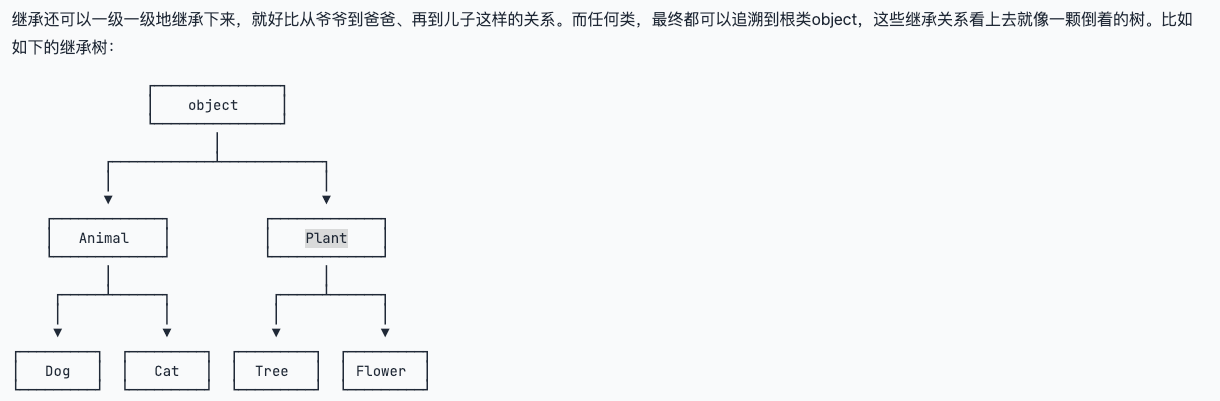

## 静态语言VS动态语言

对于静态语言（例如Java）来说，如果需要传入Animal类型，则传入的对象必须是Animal类型或者它的子类，否则，将无法调用run()方法。

对于Python这样的动态语言来说，则不一定需要传入Animal类型。我们只需要保证传入的对象有一个run()方法就可以了：

In [ ]:
class Timer(object):
    def run(self):
        print('Start...')

animal.py

In [ ]:
class Animal(object):
    def run(self):
        print("Animal is running...")


class Dog(Animal):
    def run(self):
        print("Dog is running...")


class Cat(Animal):
    def run(self):
        print("Cat is running...")


def run_twice(animal):
    animal.run()
    animal.run()


a = Animal()
d = Dog()
c = Cat()

print("a is Animal?", isinstance(a, Animal))
print("a is Dog?", isinstance(a, Dog))
print("a is Cat?", isinstance(a, Cat))

print("d is Animal?", isinstance(d, Animal))
print("d is Dog?", isinstance(d, Dog))
print("d is Cat?", isinstance(d, Cat))

run_twice(c)

get_instance.py

In [ ]:
class Animal(object):
    pass


class Dog(Animal):
    pass


class Husky(Dog):
    pass


a = Animal()
d = Dog()
h = Husky()

print("check a = Animal()...")
print("isinstance(a, Animal) =", isinstance(a, Animal))
print("isinstance(a, Dog) =", isinstance(a, Dog))
print("isinstance(a, Husky) =", isinstance(a, Husky))

print("check d = Dog()...")
print("isinstance(d, Animal) =", isinstance(d, Animal))
print("isinstance(d, Dog) =", isinstance(d, Dog))
print("isinstance(d, Husky) =", isinstance(d, Husky))

print("check h = Husky()...")
print("isinstance(h, Animal) =", isinstance(h, Animal))
print("isinstance(h, Dog) =", isinstance(h, Dog))
print("isinstance(h, Husky) =", isinstance(h, Husky))

其他教程：

https://www.yuque.com/lishibo-kipm2/rgsf35/tax1pfe5ed9ubzm6?singleDoc#

### python内置的多态例子

len()函数

In [ ]:
print(len("hello"))        # 5（字符串）
print(len([1, 2, 3]))      # 3（列表）
print(len({'a': 1, 'b': 2}))  # 2（字典）

 + 运算符

In [ ]:
print(1 + 2)              # 3（数字相加）
print("hello" + "world")  # helloworld（字符串拼接）
print([1, 2] + [3, 4])    # [1, 2, 3, 4]（列表拼接）

还有for循环

### 自己玩玩

In [17]:
class Animal(object):   #编写Animal类
    def run(self):
        print("Animal is running...")

class Dog(Animal):  #Dog类继承Amimal类，没有run方法
    pass

class Cat(Animal):  #Cat类继承Animal类，有自己的run方法
    def run(self):
        print('Cat is running...')
    pass

class Car(object):  #Car类不继承，有自己的run方法
    def run(self):
        print('Car is running...')

class Stone(object):  #Stone类不继承，也没有run方法
    pass

def run_twice(animal):
    animal.run()
    animal.run()

run_twice(Animal())
run_twice(Dog())
run_twice(Cat())
run_twice(Car())
run_twice(Stone())

Animal is running...
Animal is running...
Animal is running...
Animal is running...
Cat is running...
Cat is running...
Car is running...
Car is running...


AttributeError: 'Stone' object has no attribute 'run'